<a href="https://colab.research.google.com/github/MichalSlowakiewicz/DNN-Homeworks/blob/master/HW_1_draft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 1
---

The goal of the first homework is to become familiar with SHapley Additive exPlanations (SHAP).

Note that there are three subtasks and each is worth 50% of points.
Do two (any two) subtasks to get full credits.
Solve third one to have some extra bonus.


Submit your results on GitHub to the directory `Homeworks/HW1/FirstNameLastName` (where FirstName LastName referes to your name).


## Task A

Calculate Shapley values for player A given the following value function

```
v() = 0
v(A) = 20
v(B) = 20
v(C) = 60
v(A,B) = 60
v(A,C) = 70
v(B,C) = 70
v(A,B,C) = 100
```

In this game we have 3 diffrent players $(A, B, C)$, therefore total number of permutations is equal to $3! = 6$. Now, let us write down all the possible permutations:


1.   $A, B, C$
1.   $A, C, B$
1.   $B, A, C$
1.   $C, A, B$
1.   $B, C, A$
1.   $C, B, A$

Then, it remains to use the formula presentend on the lecture to compute Shapley values $\phi_A, \phi_B$ and $\phi_C$.

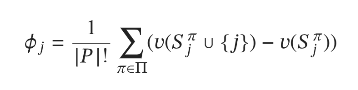



Firstly, let us compute $\phi_A$ directly from the above formula:


$$
\phi_A = \frac{1}{6} \big{[} (v(A)-v()) + (v(A)-v()) + (v(A,B)-v(B)) + (v(A,C)-v(C)) + (v(A,B,C)-v(B,C)) + (v(A,B,C)-v(B,C)) \big{]} = \frac{1}{6} \big{[} 20+20+40+10+30+30 \big{]} = 25
$$

Analogously, we obtain $\phi_B$ and $\phi_C$:

$$
\phi_B = \frac{1}{6} \big{[} (v(A,B)-v(A)) + (v(A,B,C)-v(A,C)) + (v(B)-v()) + (v(A,B,C)-v(A,C)) + (v(B)-v()) + (v(B,C)-v(C)) \big{]} = \frac{1}{6} \big{[} 40+30+20+30+20+10 \big{]} = 25
$$


$$
\phi_C = \frac{1}{6} \big{[} (v(A,B,C)-v(A,B)) + (v(A,C)-v(A)) + (v(A,B,C)-v(A,B)) + (v(C)-v()) + (v(B,C)-v(B)) + (v(C)-v()) \big{]} = \frac{1}{6} \big{[} 40+50+40+60+50+60 \big{]} = 50
$$

Finally, we obtain the answer to Task A:

$$
(\phi_A, \phi_B, \phi_C) = (25,25,50)
$$

## Task B

For this task, I have chosen the *abalone.csv* dataset from the repository. It consists of 7 columns with explanatory variables and 1 target column (target $\in \{-1, 1\}$). There are 4177 observations within this dataset.

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import shap
import matplotlib.pyplot as plt

In [12]:
# point 2

# preparing dataset for further training
df = pd.read_csv("/abalone.csv", index_col=0)

X = df.drop("TARGET", axis=1)
Y = df["TARGET"]

# 'stratify=Y' is responsible for balancing dataset with respect to 'Y' while dividing dataset
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# building model
model = RandomForestClassifier(n_estimators=10, random_state=42)
model.fit(X_train, Y_train)

# checking the results of training
Y_pred = model.predict(X_test)
print("Report:")
print(classification_report(Y_test, Y_pred))

Report:
              precision    recall  f1-score   support

          -1       0.91      0.98      0.94       758
           1       0.21      0.05      0.08        78

    accuracy                           0.89       836
   macro avg       0.56      0.52      0.51       836
weighted avg       0.84      0.89      0.86       836



In [13]:
# point 3

# let us select two observations from test dataset - one classified as 1 and one classified as -1
id_obs_1 = X_test[model.predict(X_test) == 1].index[0]
id_obs_2 = X_test[model.predict(X_test) == -1].index[0]

obs_1 = X_test.loc[id_obs_1]
obs_2 = X_test.loc[id_obs_2]

print("Classified as 1:")
print(obs_1)
print("Classified as -1:")
print(obs_2)

Classified as 1:
3    0.3500
4    0.2350
5    0.0800
6    0.1700
7    0.0725
8    0.0465
9    0.0495
Name: 1998, dtype: float64
Classified as -1:
3    0.4350
4    0.3450
5    0.1200
6    0.3215
7    0.1300
8    0.0560
9    0.1185
Name: 1844, dtype: float64


In [31]:
# point 4

def calculate_shap_manually(model, x_explain, X, n):
  """
  x_explain <- observation that we want to explain
  X <- dataset from which we are drawing features
  n <- number of permutation we want to check
  """

  features = X.columns
  shap_values = {feature: 0 for feature in features}

  for i in range(n):
    # drawing permutation of features
    permutation = np.random.permutation(features)

    # drawing observation from dataset
    obs_sample = X.sample(1).iloc[0]
    current_sample = obs_sample.copy()

    # computing initial prediction for 'obs_sample'
    pred = model.predict_proba(obs_sample.to_frame().T)[0][1]

    for feature in permutation:

      # changing feature to one from the 'x_explain' and checking the model's behaviour
      current_sample[feature] = x_explain[feature]
      new_pred = model.predict_proba(current_sample.to_frame().T)[0][1]
      change = new_pred - pred
      shap_values[feature] += change
      pred = new_pred

  # normalization
  for feature in features:
    shap_values[feature] = shap_values[feature] / n

  return shap_values


manual_shap_values_1 = calculate_shap_manually(model, obs_1, X_train, 1000)
manual_shap_values_2 = calculate_shap_manually(model, obs_2, X_train, 1000)

print("Manual Shap Values for observation 1:")
print(manual_shap_values_1)
print("Manual Shap Values for observation 2:")
print(manual_shap_values_2)

Manual Shap Values for observation 1:
{'3': np.float64(0.0158), '4': np.float64(0.12359999999999967), '5': np.float64(-0.0027000000000000027), '6': np.float64(0.1276000000000001), '7': np.float64(0.012299999999999972), '8': np.float64(0.07280000000000002), '9': np.float64(0.15809999999999977)}
Manual Shap Values for observation 2:
{'3': np.float64(0.04050000000000022), '4': np.float64(0.03500000000000006), '5': np.float64(-0.04419999999999992), '6': np.float64(0.03790000000000013), '7': np.float64(-0.03000000000000001), '8': np.float64(0.027400000000000008), '9': np.float64(0.12479999999999995)}


In [25]:
# point 5

# using in-built function from 'shap' package
shap_expl = shap.TreeExplainer(model)
shap_values_1 = shap_expl.shap_values(obs_1)[:, 1]
shap_values_2 = shap_expl.shap_values(obs_2)[:, 1]

print("Package Shap Values for observation 1:")
print(shap_values_1)
print("Package Shap Values for observation 2:")
print(shap_values_2)


Package Shap Values for observation 1:
[0.00833467 0.09678996 0.0268187  0.09648164 0.00269772 0.13353929
 0.1426113 ]
Package Shap Values for observation 2:
[0.05123588 0.00217562 0.00815264 0.03127407 0.00740283 0.03298786
 0.07404437]


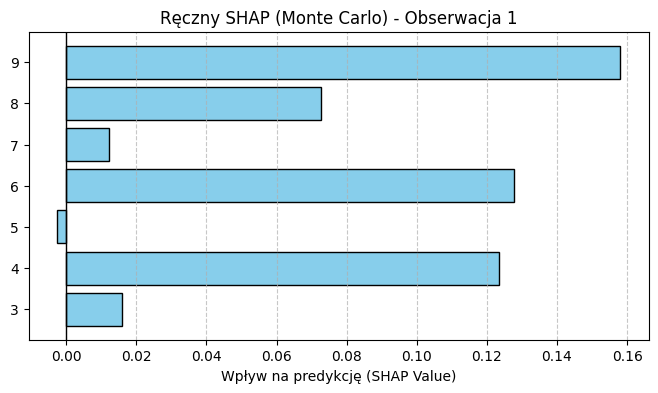

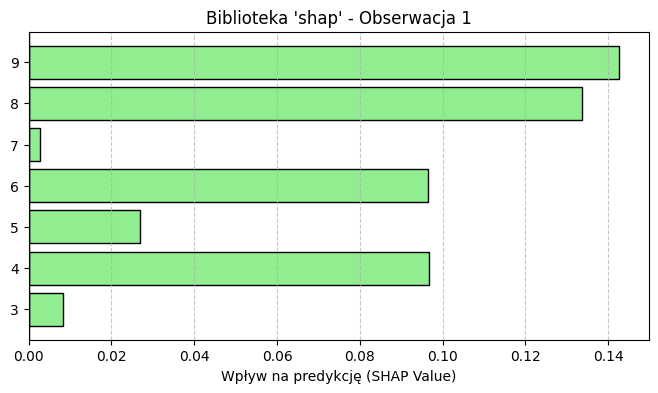

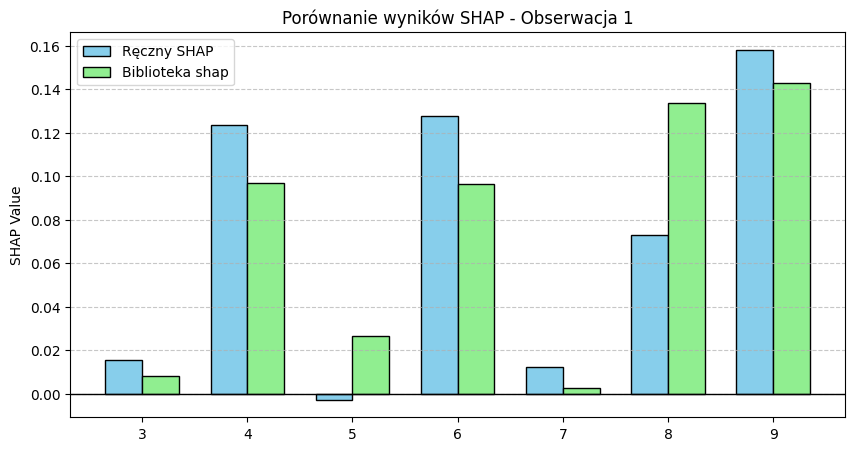

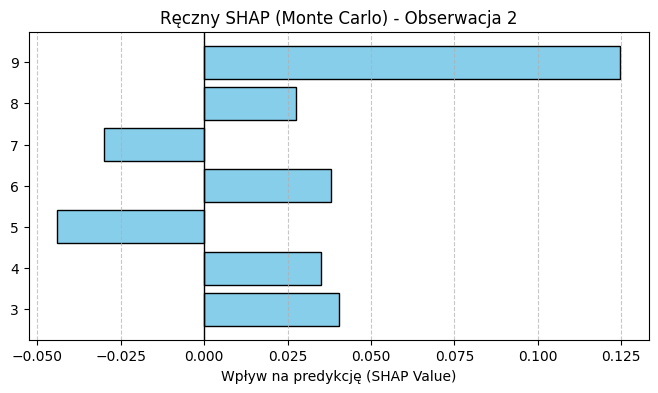

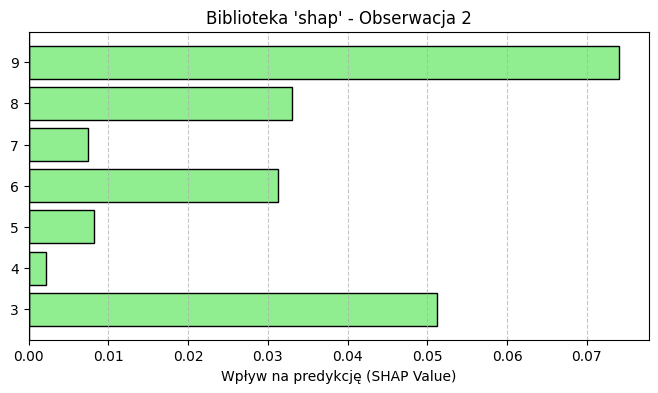

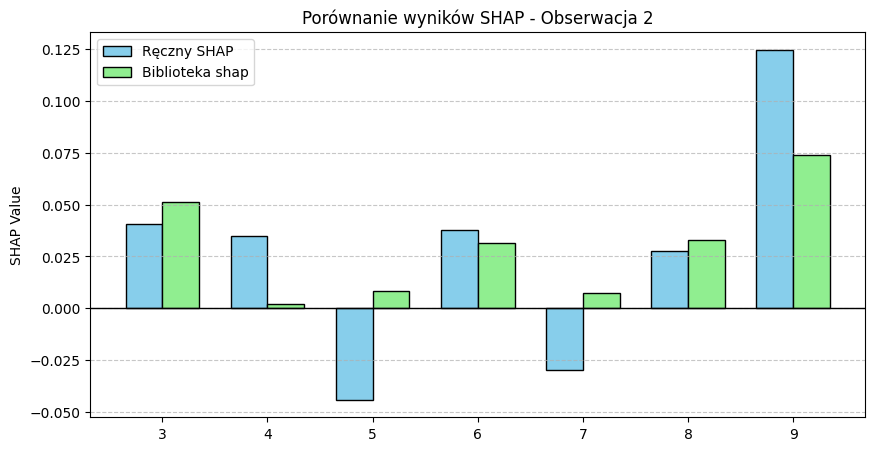

In [32]:
def plot_comparison(manual_dict, package_array, obs_name="Obserwacja"):

    features = list(manual_dict.keys())
    manual_vals = list(manual_dict.values())

    # Wartości z paczki shap (upewniamy się, że to płaska tablica)
    package_vals = np.array(package_array).flatten()

    # 2. Wykres 1: Ręczna implementacja
    plt.figure(figsize=(8, 4))
    plt.barh(features, manual_vals, color='skyblue', edgecolor='black')
    plt.title(f"Ręczny SHAP (Monte Carlo) - {obs_name}")
    plt.xlabel("Wpływ na predykcję (SHAP Value)")
    plt.axvline(0, color='black', linewidth=1) # Pionowa linia zera
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

    # 3. Wykres 2: Paczka SHAP
    plt.figure(figsize=(8, 4))
    plt.barh(features, package_vals, color='lightgreen', edgecolor='black')
    plt.title(f"Biblioteka 'shap' - {obs_name}")
    plt.xlabel("Wpływ na predykcję (SHAP Value)")
    plt.axvline(0, color='black', linewidth=1)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

    # 4. Wykres 3: Porównanie (Zgrupowany wykres słupkowy)
    x = np.arange(len(features))  # Lokalizacje etykiet na osi X
    width = 0.35  # Szerokość słupków

    plt.figure(figsize=(10, 5))
    # Słupki przesunięte w lewo i prawo, żeby stały obok siebie
    plt.bar(x - width/2, manual_vals, width, label='Ręczny SHAP', color='skyblue', edgecolor='black')
    plt.bar(x + width/2, package_vals, width, label='Biblioteka shap', color='lightgreen', edgecolor='black')

    plt.ylabel('SHAP Value')
    plt.title(f'Porównanie wyników SHAP - {obs_name}')
    plt.xticks(x, features) # Podpisujemy oś X nazwami cech
    plt.axhline(0, color='black', linewidth=1) # Pozioma linia zera
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# --- Użycie funkcji dla naszych obserwacji ---

# Generujemy wykresy dla Obserwacji 1
plot_comparison(manual_shap_values_1, shap_values_1, obs_name="Obserwacja 1")

# Generujemy wykresy dla Obserwacji 2
plot_comparison(manual_shap_values_2, shap_values_2, obs_name="Obserwacja 2")

## Task C


(a) Let us compute SHAP values using the formula that will be derived in (b):

$$
\phi_i = \beta_i (x_i - E[x_i]).
$$

Observe that $\beta_i$ values follows directly from the formula of $f$ function: $\beta_1=2$, $\beta_2=1$ and $\beta_3=3$.

Now, we can easily obtain SHAP values:

$$
\phi_1 = 2 * (1 - 0) = 2
$$

$$
\phi_2 = 1 * (1 - 0) = 1
$$

$$
\phi_3 = 3 * (1 - 0) = 3
$$

(b) In this point we will derive the formula for inear models. Since $f$ is linear we may formulate is as $f = \sum_{j \in S} \beta_j x_j$. Now, let us write value function for coalition of features S:

$$
v(S) = E[f(x) | x_S],
$$

we may transform it further:

$$
v(S) = E[f(x) | x_S]  = \sum_{j \in S} \beta_j x_j + \sum_{j ∉ S} \beta_j E[x_j]
$$

To evaluate SHAP value we are interested in the value of the difference $v(S \cup \{i\}) - v(S)$:

$$
v(S \cup \{i\}) - v(S) = (\sum_{j \in S \cup \{i\}} \beta_j x_j + \sum_{j ∉ S \cup \{i\}} \beta_j E[x_j]) - (\sum_{j \in S} \beta_j x_j + \sum_{j ∉ S} \beta_j E[x_j])= (\sum_{j \in S} \beta_j x_j + \beta_i x_i + \sum_{j ∉ S \cup \{i\}} \beta_j E[x_j]) - (\sum_{j \in S} \beta_j x_j + \sum_{j ∉ S \cup \{i\}} \beta_j E[x_j] + \beta_i E[x_i]) = \beta_i x_i - \beta_i E[x_i]
$$


Question: Does this follow from the axioms, or from the particular structure of the game?

This follows from the stracture of the game - the linear model is additive and the variables are independant, what guarantees the contribution any feature is always the same, no matter what other features are currently present in coalition.

(c) When $x_1$ and $x_2$ are strongly correlated, the addition of the second variable to the model introduces little new information/value if we already have the first one. Therefore, while calculating SHAP, the variable which is added to the coalition first will claim the majority of marginal contribution. However, since SHAP values are averaged across all possible permutations, this will not result in collapse of SHAP values and they will be computed properly despite huge correlation.

The symmetry property will still be satisfied. This property states that if two variables contribute identically to all possible coalitions, they will have the same SHAP value. As explained earlier, because of the high correlation, the first variable added will claim the majority of the reward. However, because we average the result over all possible permutations, we will get rid of possible injustice reagarding which variable was added first. As a result, the symmetry property remains valid.